In [1]:
# library for feature engineering and EDA
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image
import pandas_profiling
from datetime import datetime
import random

# library for statistic
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, f_oneway
from scipy.stats import boxcox, norm
from scipy.stats import bartlett
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# library for sampling 
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SVMSMOTE

# library for machine learning
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import shap
%matplotlib inline

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_2464\3343956858.py:8: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling


In [2]:
df = pd.read_csv("data/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Duplicated :", len(df[df.duplicated()])) 

Duplicated : 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
for column_name in list(df.columns):
    print(column_name, df[column_name].dtype, df[column_name].unique()) # column name, data type and show unique data values

UDI int64 [    1     2     3 ...  9998  9999 10000]
Product ID object ['M14860' 'L47181' 'L47182' ... 'M24857' 'H39412' 'M24859']
Type object ['M' 'L' 'H']
Air temperature [K] float64 [298.1 298.2 298.3 298.5 298.4 298.6 298.7 298.8 298.9 299.  299.1 298.
 297.9 297.8 297.7 297.6 297.5 297.4 297.3 297.2 297.1 297.  296.9 296.8
 296.7 296.6 296.5 296.3 296.4 296.2 296.1 296.  295.9 295.8 295.7 295.6
 295.5 295.4 295.3 299.2 299.3 299.5 299.4 299.6 299.7 299.8 299.9 300.
 300.1 300.2 300.3 300.4 300.5 300.6 300.7 300.8 300.9 301.  301.1 301.2
 301.3 301.4 301.5 301.6 301.7 301.8 301.9 302.  302.1 302.2 302.3 302.4
 302.5 302.6 302.7 302.8 302.9 303.  303.1 303.2 303.3 303.4 303.5 303.6
 303.7 303.8 303.9 304.  304.1 304.2 304.3 304.4 304.5]
Process temperature [K] float64 [308.6 308.7 308.5 309.  308.9 309.1 309.2 309.3 309.4 309.5 308.8 308.4
 308.3 308.2 308.1 308.  307.9 309.6 309.7 309.8 309.9 310.  310.1 310.2
 307.8 307.7 307.6 307.5 307.4 307.3 307.2 307.1 307.  306.9 306.8 306.7


In [7]:
list_cast_to_object = ["UDI", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
for column_name in list_cast_to_object:
  df[column_name] = df[column_name].astype(object) # int 64 needs to be categorical value to cast into object type

In [8]:
list_categorical_columns = list(df.select_dtypes(include=['object']).columns) # dataframe, select data types objects
list_numeric_columns = list(df.select_dtypes(include=['float64','int64']).columns) # dataframe, select data types floats and ints
target_column = "Machine failure" 
print(len(df))
print(len(df.columns))
print(len(list_categorical_columns))
print(len(list_numeric_columns))

10000
14
9
5


In [9]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [10]:
list_categorical_columns.remove(target_column)

In [11]:
df[target_column].describe()

count     10000
unique        2
top           0
freq       9661
Name: Machine failure, dtype: int64

In [12]:
df[target_column].value_counts()/10000*100

Machine failure
0    96.61
1     3.39
Name: count, dtype: float64

In [13]:
df[list_categorical_columns].nunique().sort_values()

TWF               2
HDF               2
PWF               2
OSF               2
RNF               2
Type              3
UDI           10000
Product ID    10000
dtype: int64

In [14]:
# Remove unique ids
df = df.drop(["UDI","Product ID"], axis=1)
list_categorical_columns.remove("UDI")
list_categorical_columns.remove("Product ID")

In [15]:

df = df.drop(["TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)
list_categorical_columns.remove("TWF")
list_categorical_columns.remove("HDF")
list_categorical_columns.remove("PWF")
list_categorical_columns.remove("OSF")
list_categorical_columns.remove("RNF")

In [16]:
list_categorical_columns

['Type']

In [17]:
df["Type"]

0       M
1       L
2       L
3       L
4       L
       ..
9995    M
9996    H
9997    M
9998    H
9999    M
Name: Type, Length: 10000, dtype: object

<Axes: xlabel='Type'>

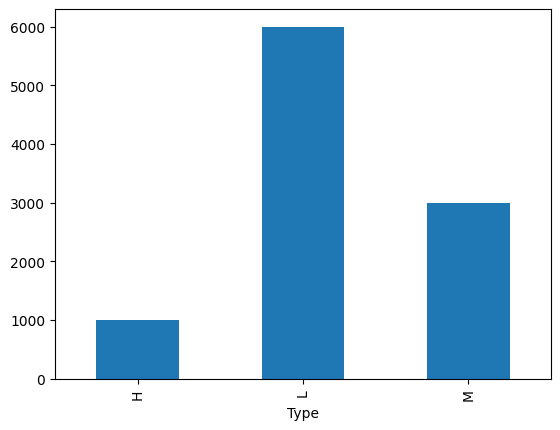

In [19]:
df["Type"].value_counts().sort_index().plot(kind='bar')

In [20]:

pd.crosstab(df[target_column], df[list_categorical_columns[0]])

Type,H,L,M
Machine failure,,,
0,982,5765,2914
1,21,235,83


<Axes: xlabel='Machine failure'>

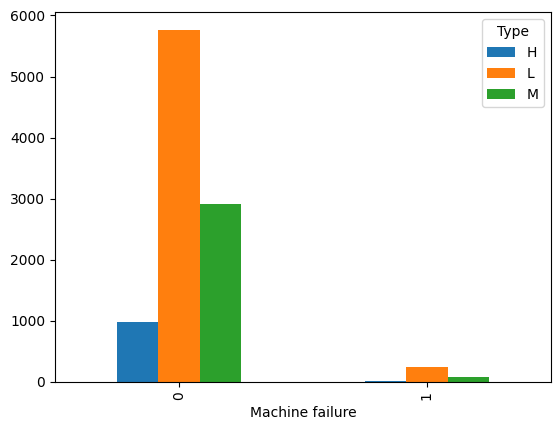

In [21]:
df_poutcome_dependent = pd.crosstab(df[target_column], df[list_categorical_columns[0]])
df_poutcome_dependent.plot(kind='bar')

# 애초에 target_column(y) 비중이 다르기 때문에, 아래와 같이 count 수를 비교하는 것은 데이터 분포를 파악하는데 적합하지 않음

In [22]:
pd.crosstab(df[target_column], df[list_categorical_columns[0]], normalize="index")

Type,H,L,M
Machine failure,,,
0,0.101646,0.596729,0.301625
1,0.061947,0.693215,0.244838


<Axes: xlabel='Machine failure'>

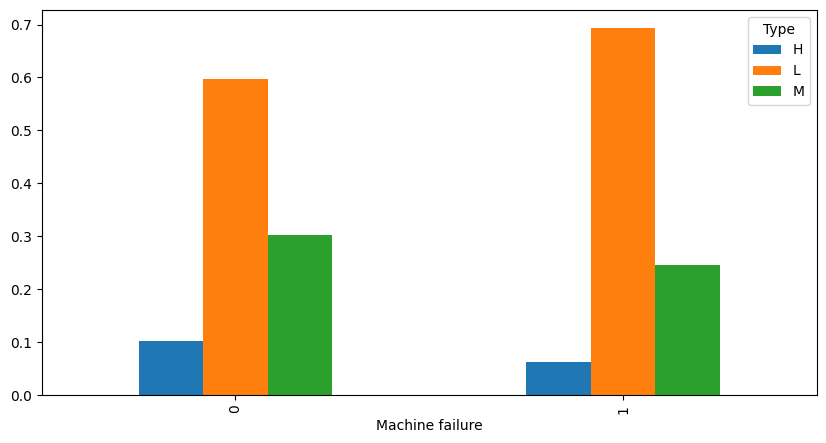

In [23]:
df_poutcome_dependent_ratio = pd.crosstab(df[target_column], df[list_categorical_columns[0]], normalize="index")
df_poutcome_dependent_ratio.plot.bar(figsize=(10,5))